# Modelado Predictivo de Riesgo de Puntos Críticos
En este notebook entrenaremos y compararemos Regresión Logística, Random Forest y Gradient Boosting. También usaremos SHAP para interpretabilidad y K-Means para descubrir zonas territoriales.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.cluster import KMeans

# Definir directorios
MODEL_BASE = '../03_MODELO'
DATASET_DIR = f'{MODEL_BASE}/01_dataset_modelo'
TRAINED_DIR = f'{MODEL_BASE}/04_modelos_guardados'
PRED_DIR = f'{MODEL_BASE}/05_predicciones'
RESULTS_DIR = f'{MODEL_BASE}/07_resultados'
EXPLAIN_DIR = f'{MODEL_BASE}/06_explicabilidad'

# Cargar dataset
df_geo = gpd.read_file(f'{DATASET_DIR}/dataset_modelo.gpkg')
df = df_geo.drop(columns='geometry').copy()
print("Dataset cargado:", df.shape)

Dataset cargado: (5781, 8)


In [2]:
# 1. Definir Features y Target
# Features: descartamos el id_celda, y el target. También descartamos la cantidad de puntos críticos ya que el target está basado en él (para evitar Leakage directo si queremos predecir nuevas zonas)

# RECALCULAR TARGET CORRECTAMENTE (El target previo era 1 para todo debido a cuantiles 0)
umbral_reportes = df[df['num_reportes'] > 0]['num_reportes'].quantile(0.75) if df['num_reportes'].max() > 0 else 1
df['target_riesgo'] = np.where((df['num_puntos_criticos'] > 0) | (df['num_reportes'] >= umbral_reportes), 1, 0)
print("Distribución corregida del target:", df['target_riesgo'].value_counts().to_dict())

features = ['num_reportes', 'num_cestas', 'tiene_macroruta', 'dist_cesta_mas_cercana', 'dist_punto_critico']
target = 'target_riesgo'

X = df[features]
y = df[target]

# Split de los datos
# Idealmente Spatial CV, usaremos train_test_split con stratify para mantener la proporción de riesgo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Distribución corregida del target: {0: 5354, 1: 427}
Train size: (4335, 5) Test size: (1446, 5)


In [3]:
# 2. Entrenamiento y Evaluación de Modelos

modelos = {
    'Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

resultados = []

for nombre, modelo in modelos.items():
    # Entrenar
    modelo.fit(X_train, y_train)
    
    # Guardar modelo
    joblib.dump(modelo, f"{TRAINED_DIR}/modelo_{nombre.replace(' ', '_').lower()}.pkl")
    
    # Predecir
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, 'predict_proba') else [0]*len(y_test)
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_proba) if len(np.unique(y_test))>1 else 0
    
    resultados.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,  # Fundamental no dejar falsos negativos
        'F1': f1,
        'ROC-AUC': roc
    })

df_resultados = pd.DataFrame(resultados)
print("\n--- RESULTADOS DE LOS MODELOS ---")
print(df_resultados)
df_resultados.to_csv(f"{RESULTS_DIR}/matriz_modelos.csv", index=False)


--- RESULTADOS DE LOS MODELOS ---
              Modelo  Accuracy  Precision    Recall        F1   ROC-AUC
0          Logística  0.987552   0.900901  0.934579  0.917431  0.998276
1      Random Forest  0.984786   0.889908  0.906542  0.898148  0.993254
2  Gradient Boosting  0.985477   0.890909  0.915888  0.903226  0.996433


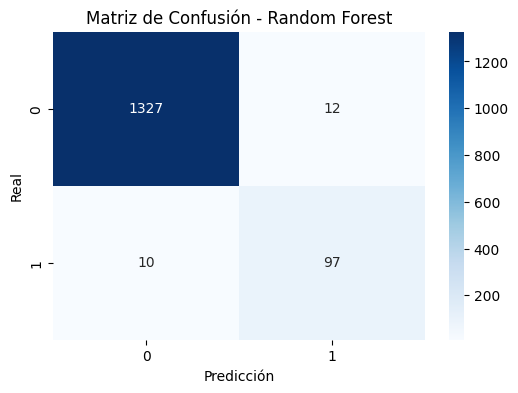

In [4]:
# 3. Matriz de Confusión del Mejor Modelo (asumamos Random Forest como principal)
best_model = modelos['Random Forest']
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.savefig(f"{RESULTS_DIR}/matriz_confusion.png")
plt.show()


Feature Importance:
                   Feature  Importancia
4      dist_punto_critico     0.928463
3  dist_cesta_mas_cercana     0.033740
0            num_reportes     0.022480
1              num_cestas     0.015099
2         tiene_macroruta     0.000217


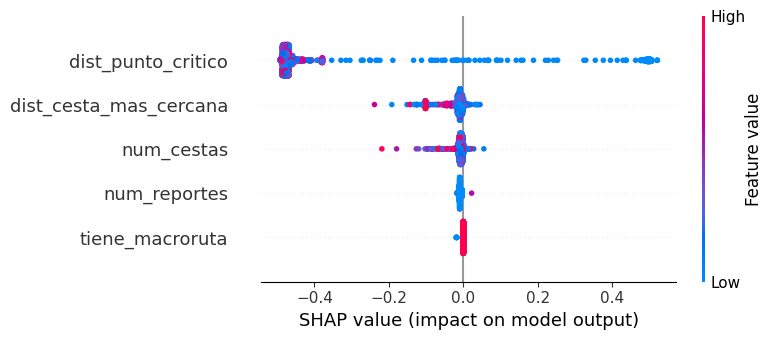

In [5]:
# 4. Interpretabilidad: Feature Importance y SHAP
# Feature Importance de Random Forest
importances = best_model.feature_importances_
fi_df = pd.DataFrame({'Feature': features, 'Importancia': importances}).sort_values(by='Importancia', ascending=False)
print("\nFeature Importance:\n", fi_df)
fi_df.to_csv(f"{EXPLAIN_DIR}/feature_importance.csv", index=False)

# SHAP
# Usamos TreeExplainer para Random Forest
explainer = shap.TreeExplainer(best_model)
shap_obj = explainer(X_test)

# Manejar diferentes formatos devueltos por versiones de SHAP
if hasattr(shap_obj, 'values') and len(shap_obj.values.shape) == 3:
    shap_vals_plot = shap_obj[:, :, 1]
elif isinstance(shap_obj, list):
    shap_vals_plot = shap_obj[1]
else:
    shap_vals_plot = shap_obj

# Graficar SHAP summary plot
plt.figure()
shap.summary_plot(shap_vals_plot, X_test, show=False)
plt.savefig(f"{EXPLAIN_DIR}/shap_summary.png", bbox_inches='tight')
plt.show()

In [6]:
# 5. Clustering con K-Means
# Normalizamos las features numéricas para clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_geo['cluster'] = clusters
print("\nDistribución de clusters:\n", df_geo['cluster'].value_counts())


Distribución de clusters:
 cluster
0    4461
1    1293
2      27
Name: count, dtype: int64


In [7]:
# 6. Predicción Final sobre toda Bogotá y guardado
# Calculamos la probabilidad de riesgo para TODA la grilla
probabilidades = best_model.predict_proba(X)[:, 1]
df_geo['probabilidad_riesgo'] = probabilidades

# Clasificación (Alto, Medio, Bajo)
df_geo['nivel_riesgo'] = np.where(probabilidades >= 0.67, '🔴 Alto',
                                  np.where(probabilidades >= 0.34, '🟡 Medio', '🟢 Bajo'))

# Asignar prioridad de intervención básica
# Prioridad = Probabilidad * num_reportes (como variable de persistencia)
df_geo['indice_prioridad'] = df_geo['probabilidad_riesgo'] * (df_geo['num_reportes'] + 1)
df_geo = df_geo.sort_values(by='indice_prioridad', ascending=False)

# Definir Acción Recomendada basada en reglas y riesgo
def recomendar_accion(row):
    if row['nivel_riesgo'] == '🔴 Alto':
        if row['tiene_macroruta'] == 0:
            return 'Priorizar revisión de cobertura de barrido'
        elif row['num_cestas'] == 0:
            return 'Evaluar instalación de infraestructura de cestas'
        else:
            return 'Inspección prioritaria por alta concentración'
    elif row['nivel_riesgo'] == '🟡 Medio':
        return 'Monitoreo preventivo'
    else:
        return 'Seguimiento normal'

df_geo['accion_recomendada'] = df_geo.apply(recomendar_accion, axis=1)

# Guardar la capa de salida predictiva
df_geo.to_file(f"{PRED_DIR}/riesgo_predicho.gpkg", driver='GPKG')

# Guardar top de zonas prioritarias
top_zonas = df_geo[['id_celda', 'nivel_riesgo', 'probabilidad_riesgo', 'indice_prioridad', 'accion_recomendada']].head(20)
top_zonas.to_csv(f"{RESULTS_DIR}/ranking_zonas.csv", index=False)
print("\nPredicciones guardadas exitosamente.")


Predicciones guardadas exitosamente.
